# Clinical MRI Classification

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Set random seed for reproducibility
tf.keras.utils.set_random_seed(42)

2026-03-23 16:08:17.961850: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774282098.203425      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774282098.270973      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774282098.809039      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774282098.809089      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774282098.809096      55 computation_placer.cc:177] computation placer alr

## Step 1: Data Loading & Preprocessing
Load your MRI dataset, normalise the pixel values, and verify the shapes of your Train, Validation, and Test splits.

Found 5600 files belonging to 4 classes.
Using 5040 files for training.


I0000 00:00:1774282128.343426      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774282128.349524      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 5600 files belonging to 4 classes.
Using 560 files for validation.
Found 1600 files belonging to 4 classes.
Train batches : 158
Val batches   : 18
Test batches  : 50
Image batch shape : (32, 224, 224, 3)
Label batch shape : (32,)
Pixel range       : [0.000, 1.000]


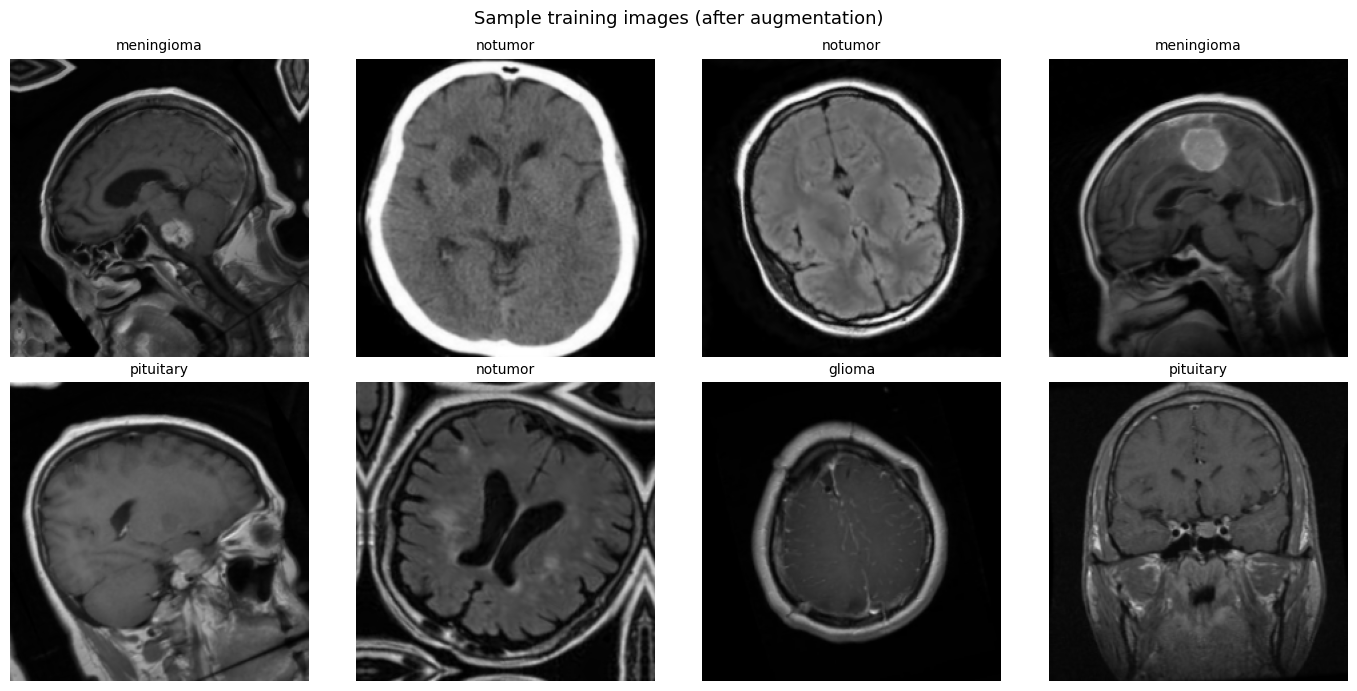

In [2]:
# ── Configuration ────────────────────────────────────────────────────────────
# The dataset already provides a Training folder and a Testing folder.
# We load them directly — no manual splitting needed.
TRAIN_DIR   = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training"
TEST_DIR    = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing"
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
CLASS_NAMES = ["glioma", "meningioma", "notumor", "pituitary"]

# ── Load Training set (with 10 % carved out as validation) ──────────────────
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels          = "inferred",
    label_mode      = "int",
    class_names     = CLASS_NAMES,
    image_size      = IMG_SIZE,
    batch_size      = BATCH_SIZE,
    validation_split= 0.10,
    subset          = "training",
    seed            = 42,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels          = "inferred",
    label_mode      = "int",
    class_names     = CLASS_NAMES,
    image_size      = IMG_SIZE,
    batch_size      = BATCH_SIZE,
    validation_split= 0.10,
    subset          = "validation",
    seed            = 42,
)

# ── Load the provided Test set (used only for final evaluation) ──────────────
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels      = "inferred",
    label_mode  = "int",
    class_names = CLASS_NAMES,
    image_size  = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    shuffle     = False,   # keep order deterministic for evaluation
)

# ── Normalisation (0-255 → 0-1) ──────────────────────────────────────────────
normalization = tf.keras.layers.Rescaling(1.0 / 255)

# ── Data augmentation applied only during training ───────────────────────────
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.10),
    tf.keras.layers.RandomZoom(0.10),
], name="augmentation")

def preprocess_train(images, labels):
    images = normalization(images)
    images = augmentation(images, training=True)
    return images, labels

def preprocess_eval(images, labels):
    images = normalization(images)
    return images, labels

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(preprocess_train, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds   = val_ds.map(preprocess_eval,   num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds  = test_ds.map(preprocess_eval,  num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

# ── Sanity check ─────────────────────────────────────────────────────────────
print("Train batches :", tf.data.experimental.cardinality(train_ds).numpy())
print("Val batches   :", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches  :", tf.data.experimental.cardinality(test_ds).numpy())

# Visualise a sample batch
sample_images, sample_labels = next(iter(train_ds))
print("Image batch shape :", sample_images.shape)   # (32, 224, 224, 3)
print("Label batch shape :", sample_labels.shape)   # (32,)
print("Pixel range       : [{:.3f}, {:.3f}]".format(
    sample_images.numpy().min(), sample_images.numpy().max()))

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, img, lbl in zip(axes.flat, sample_images[:8], sample_labels[:8]):
    ax.imshow(img.numpy())
    ax.set_title(CLASS_NAMES[lbl], fontsize=10)
    ax.axis("off")
plt.suptitle("Sample training images (after augmentation)", fontsize=13)
plt.tight_layout()
plt.show()

## Step 2: CNN Architecture Design
Build your custom model. Ensure you include regularisation (Dropout or L2) and print the model summary. Write a brief justification for your parameter count below the output.

In [3]:
from tensorflow.keras import layers, models, regularizers

L2 = 1e-4   # L2 regularisation strength

def build_cnn(input_shape=(224, 224, 3), num_classes=4):
    """Custom CNN for brain-tumour MRI classification."""
    inputs = tf.keras.Input(shape=input_shape, name="input")

    # ── Block 1: 32 filters ──────────────────────────────────────────────────
    x = layers.Conv2D(32, 3, padding="same",
                      kernel_regularizer=regularizers.l2(L2), name="conv1")(inputs)
    x = layers.BatchNormalization(name="bn1")(x)
    x = layers.Activation("relu", name="relu1")(x)
    x = layers.MaxPooling2D(2, name="pool1")(x)          # 224 → 112

    # ── Block 2: 64 filters ──────────────────────────────────────────────────
    x = layers.Conv2D(64, 3, padding="same",
                      kernel_regularizer=regularizers.l2(L2), name="conv2")(x)
    x = layers.BatchNormalization(name="bn2")(x)
    x = layers.Activation("relu", name="relu2")(x)
    x = layers.MaxPooling2D(2, name="pool2")(x)          # 112 → 56

    # ── Block 3: 128 filters ─────────────────────────────────────────────────
    x = layers.Conv2D(128, 3, padding="same",
                      kernel_regularizer=regularizers.l2(L2), name="conv3")(x)
    x = layers.BatchNormalization(name="bn3")(x)
    x = layers.Activation("relu", name="relu3")(x)
    x = layers.MaxPooling2D(2, name="pool3")(x)          # 56 → 28

    # ── Block 4: 256 filters ─────────────────────────────────────────────────
    x = layers.Conv2D(256, 3, padding="same",
                      kernel_regularizer=regularizers.l2(L2), name="conv4")(x)
    x = layers.BatchNormalization(name="bn4")(x)
    x = layers.Activation("relu", name="relu4")(x)
    x = layers.MaxPooling2D(2, name="pool4")(x)          # 28 → 14

    # ── Classifier head ──────────────────────────────────────────────────────
    x = layers.GlobalAveragePooling2D(name="gap")(x)     # 14×14×256 → 256
    x = layers.Dense(512, activation="relu",
                     kernel_regularizer=regularizers.l2(L2), name="dense1")(x)
    x = layers.Dropout(0.5, name="drop1")(x)
    x = layers.Dense(256, activation="relu",
                     kernel_regularizer=regularizers.l2(L2), name="dense2")(x)
    x = layers.Dropout(0.3, name="drop2")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)

    return models.Model(inputs, outputs, name="BrainTumour_CNN")


model = build_cnn()
model.summary()
print(f"\nTotal trainable parameters: {model.count_params():,}")

Model: "BrainTumour_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (Activation)              │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (Activation)              │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (Activation)              │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 28, 28, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu4 (Activation)              │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 654,276 (2.50 MB)

 Trainable params: 653,316 (2.49 MB)

 Non-trainable params: 960 (3.75 KB)


Total trainable parameters: 654,276


### Parameter count justification

The model contains **654,276 trainable parameters**, which is reasonable relative to the effective training set size of **5,040 images** because the network uses strong regularisation through **Dropout** (50 % and 30 %), **L2 weight regularisation** (lambda = 1e-4), and **EarlyStopping**, allowing this capacity to generalise without relying on an excessively large fully connected head.

## Step 3: Training Dynamics
Compile your model and train it. You must include the EarlyStopping callback. Plot your training and validation loss curves.

Epoch 1/50


I0000 00:00:1774282138.521575     131 service.cc:152] XLA service 0x7c8794019220 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774282138.521612     131 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774282138.521616     131 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774282139.456963     131 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/158 ━━━━━━━━━━━━━━━━━━━━ 15s 98ms/step - accuracy: 0.2656 - loss: 1.7578 

I0000 00:00:1774282147.555924     131 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


158/158 ━━━━━━━━━━━━━━━━━━━━ 46s 211ms/step - accuracy: 0.5700 - loss: 1.1239 - val_accuracy: 0.2321 - val_loss: 3.0901 - learning_rate: 0.0010
Epoch 2/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 24s 148ms/step - accuracy: 0.6856 - loss: 0.8738 - val_accuracy: 0.3393 - val_loss: 3.2604 - learning_rate: 0.0010
Epoch 3/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 24s 147ms/step - accuracy: 0.7467 - loss: 0.7363 - val_accuracy: 0.6446 - val_loss: 1.0588 - learning_rate: 0.0010
Epoch 4/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 23s 145ms/step - accuracy: 0.7714 - loss: 0.6788 - val_accuracy: 0.5339 - val_loss: 1.4857 - learning_rate: 0.0010
Epoch 5/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 23s 145ms/step - accuracy: 0.7858 - loss: 0.6547 - val_accuracy: 0.5018 - val_loss: 1.3773 - learning_rate: 0.0010
Epoch 6/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 23s 145ms/step - accuracy: 0.7971 - loss: 0.6219 - val_accuracy: 0.7607 - val_loss: 0.7230 - learning_rate: 0.0010
Epoch 7/50
158/158 ━━━━━━━━━━━━━━━━━━━━ 23s 145ms/step - accuracy: 0.8177 - loss:

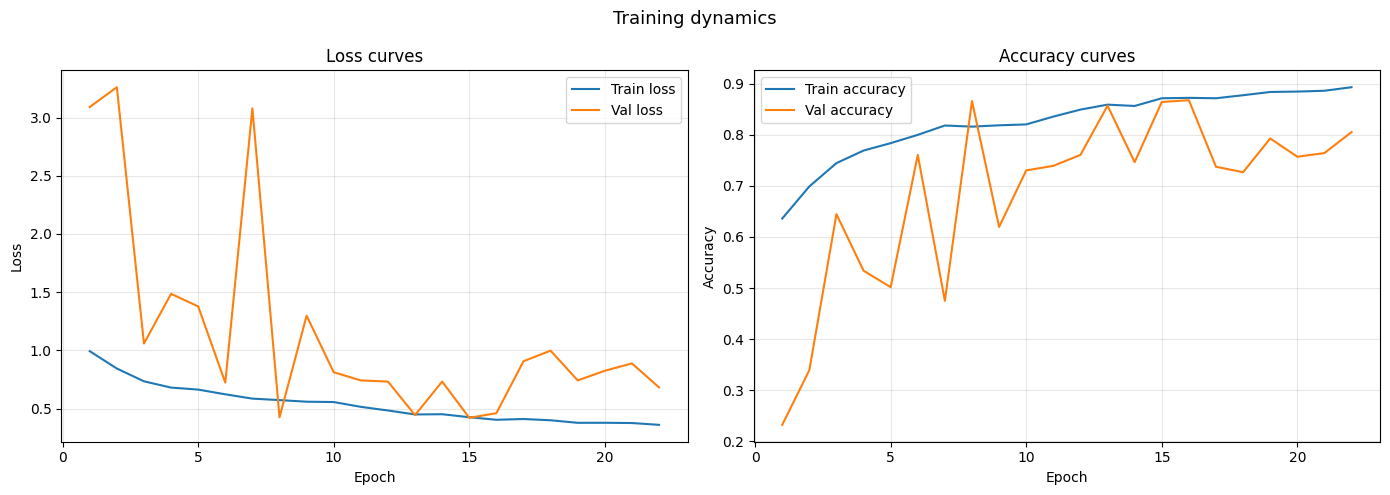


Best val accuracy : 0.8679
Stopped at epoch  : 22


In [4]:
# ── Compile ──────────────────────────────────────────────────────────────────
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss      = "sparse_categorical_crossentropy",
    metrics   = ["accuracy"],
)

# ── Callbacks ────────────────────────────────────────────────────────────────
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor              = "val_loss",
    patience             = 7,
    restore_best_weights = True,
    verbose              = 1,
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor  = "val_loss",
    factor   = 0.5,
    patience = 3,
    verbose  = 1,
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor              = "val_accuracy",
    save_best_only       = True,
    verbose              = 0,
)

# ── Train ────────────────────────────────────────────────────────────────────
history = model.fit(
    train_ds,
    epochs          = 50,
    validation_data = val_ds,
    callbacks       = [early_stop, lr_scheduler, checkpoint],
)

# ── Plot training curves ──────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_ran = range(1, len(history.history["loss"]) + 1)

ax1.plot(epochs_ran, history.history["loss"],     label="Train loss")
ax1.plot(epochs_ran, history.history["val_loss"], label="Val loss")
ax1.set_title("Loss curves")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_ran, history.history["accuracy"],     label="Train accuracy")
ax2.plot(epochs_ran, history.history["val_accuracy"], label="Val accuracy")
ax2.set_title("Accuracy curves")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Training dynamics", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nBest val accuracy : {max(history.history['val_accuracy']):.4f}")
print(f"Stopped at epoch  : {len(history.history['loss'])}")

## Step 4: Clinical Evaluation
Generate predictions on your test set. Print the classification report and plot a 4x4 confusion matrix. Prioritise Recall in your analysis.

Classification Report
              precision    recall  f1-score   support

      glioma     0.8488    0.6875    0.7597       400
  meningioma     0.7151    0.6525    0.6824       400
     notumor     0.8058    0.9650    0.8783       400
   pituitary     0.8449    0.9125    0.8774       400

    accuracy                         0.8044      1600
   macro avg     0.8036    0.8044    0.7994      1600
weighted avg     0.8036    0.8044    0.7994      1600

Per-class Recall (clinically critical metric):
  glioma         : 0.6875
  meningioma     : 0.6525
  notumor        : 0.9650 ← CRITICAL (False Negatives = missed tumour)
  pituitary      : 0.9125


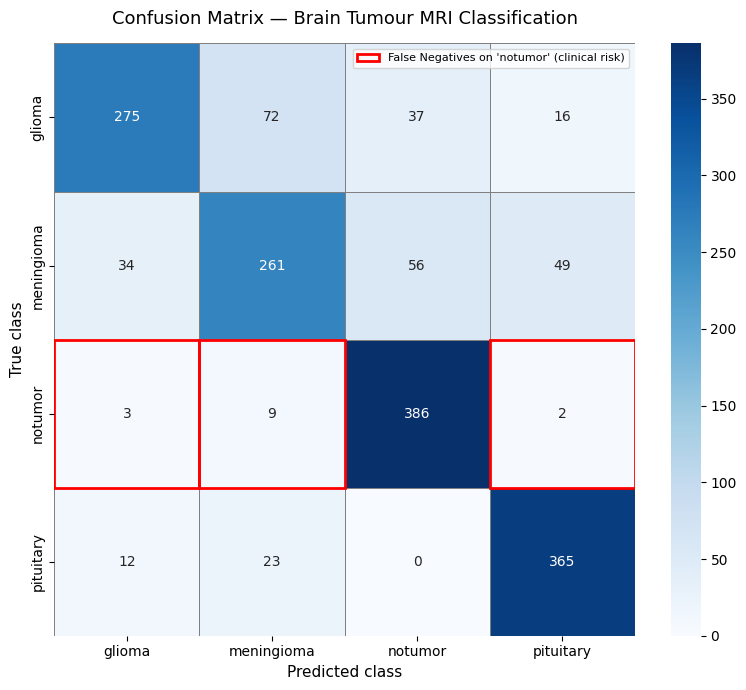


Test accuracy : 0.8044
Test loss     : 0.7128


In [5]:
# ── Collect ground-truth labels and predictions from test set ────────────────
y_true, y_pred_probs = [], []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred_probs.extend(probs)

y_true       = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred       = np.argmax(y_pred_probs, axis=1)

# ── Classification report (per-class Recall highlighted) ────────────────────
print("=" * 60)
print("Classification Report")
print("=" * 60)
print(classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES,
    digits=4,
))

# Extract and print per-class recall explicitly
from sklearn.metrics import recall_score
recalls = recall_score(y_true, y_pred, average=None)
print("Per-class Recall (clinically critical metric):")
for cls, rec in zip(CLASS_NAMES, recalls):
    flag = " ← CRITICAL (False Negatives = missed tumour)" if cls == "notumor" else ""
    print(f"  {cls:<15}: {rec:.4f}{flag}")

# ── 4×4 Confusion matrix ─────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    cm,
    annot        = True,
    fmt          = "d",
    cmap         = "Blues",
    xticklabels  = CLASS_NAMES,
    yticklabels  = CLASS_NAMES,
    linewidths   = 0.5,
    linecolor    = "grey",
    ax           = ax,
)

ax.set_title("Confusion Matrix — Brain Tumour MRI Classification", fontsize=13, pad=14)
ax.set_xlabel("Predicted class", fontsize=11)
ax.set_ylabel("True class",      fontsize=11)
ax.xaxis.set_label_position("bottom")
ax.xaxis.tick_bottom()

# Highlight the notumor row to draw attention to False Negatives
notumor_idx = CLASS_NAMES.index("notumor")
for j in range(len(CLASS_NAMES)):
    if j != notumor_idx:
        ax.add_patch(plt.Rectangle(
            (j, notumor_idx), 1, 1,
            fill=False, edgecolor="red", lw=2,
            label="False Negatives on 'notumor' (clinical risk)" if j == 0 else ""
        ))

ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

# ── Final test accuracy ───────────────────────────────────────────────────────
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"\nTest accuracy : {test_acc:.4f}")
print(f"Test loss     : {test_loss:.4f}")